# Bellabeat Case Study

Author: Indah Ayu Permatasari

Date: 16 February 2023

***

# 1. ASK

#### 1.1 Background
Bellabeat is a data-centered femtech company that manufactures health-focused wearable technology. It is best known for its Leaf smart jewelry wearable line that is created only for women and tracks sleep, steps, menstrual cycle, mindfulness, and activity.

#### 1.2 Business Task:

- Getting insight about how consumers using their smart devices through analyzing FitBit Fitness Tracker Data
- Discover insight from the data in order to help guide marketing strategy for the company.

#### 1.3 Business research question:  
1. What are the trends identified?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

#### 1.4 Key Stakeholders:
1. Urška Sršen: Bellabeat’s cofounder and Chief Creative Officer
2. Sando Mur: Mathematician, Bellabeat’s cofounder and key member of the Bellabeat executive team
3. Bellabeat marketing analytics team: A team of data analysts guiding Bellabeat's marketing strategy.

***


# STEP 2: PREPARE


#### 2.1 Data Source Information
Data for this analysis is publicly available on [Kaggle: FitBit Fitness Tracker Data](https://www.kaggle.com/arashnic/fitbit) and stored in 18 csv files. This dataset generated by respondents to a distributed survey via Amazon Mechanical Turk between 03.12.2016-05.12.2016. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring.

    
#### 2.2 Limitations of Data Set

Data has limitation in size.The number of users is just 30 users so we are not sure if the sample is representative of the population as a whole and also there is limitation in the time of survey i.e just 2 months long.

#### 2.3 Data Selection
The following file is selected for analysis.
```
    *   dailyActivity_merged.csv
    *   sleepDay_merged
    *   hourlyCalories_merged
    *   hourlyIntensities_merged
    *   hourlySteps_merged
    
We didn't use minute data because it has summarize by hourly data and also we didn't use weightloginfo and heart rate data.
```

# STEP 3: PROCESS

#### 3.1 Preparing the Environment

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib as plt
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

#### 3.2 Importing data set

Reading in the selected file.

In [2]:
from google.colab import files
upload = files.upload()

Saving dailyActivity_merged.csv to dailyActivity_merged.csv
Saving hourlyCalories_merged.csv to hourlyCalories_merged.csv
Saving hourlyIntensities_merged.csv to hourlyIntensities_merged.csv
Saving hourlySteps_merged.csv to hourlySteps_merged.csv
Saving sleepDay_merged.csv to sleepDay_merged.csv


In [3]:
dailyActivity = pd.read_csv(r"dailyActivity_merged.csv")
dailySleep = pd.read_csv(r'sleepDay_merged.csv')
# Hourly
hourlyCalories = pd.read_csv(r'hourlyCalories_merged.csv')
hourlyIntensities = pd.read_csv(r'hourlyIntensities_merged.csv')
hourlySteps = pd.read_csv(r'hourlySteps_merged.csv')

#### 3.3 Data cleaning and manipulation

In [4]:
dailyActivity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [5]:
dailySleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [6]:
hourlyCalories.head()

,Id,ActivityHour,Calories
0,1503960366,4/12/2016 12:00:00 AM,81
1,1503960366,4/12/2016 1:00:00 AM,61
2,1503960366,4/12/2016 2:00:00 AM,59
3,1503960366,4/12/2016 3:00:00 AM,47
4,1503960366,4/12/2016 4:00:00 AM,48


In [7]:
hourlyIntensities.head()

,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1503960366,4/12/2016 12:00:00 AM,20,0.333333
1,1503960366,4/12/2016 1:00:00 AM,8,0.133333
2,1503960366,4/12/2016 2:00:00 AM,7,0.116667
3,1503960366,4/12/2016 3:00:00 AM,0,0.000000
4,1503960366,4/12/2016 4:00:00 AM,0,0.000000


In [8]:
hourlySteps.head()

,Id,ActivityHour,StepTotal
0,1503960366,4/12/2016 12:00:00 AM,373
1,1503960366,4/12/2016 1:00:00 AM,160
2,1503960366,4/12/2016 2:00:00 AM,151
3,1503960366,4/12/2016 3:00:00 AM,0
4,1503960366,4/12/2016 4:00:00 AM,0


In [9]:
dailyActivity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [10]:
dailySleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


In [11]:
hourlyCalories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   Calories      22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


In [12]:
hourlyIntensities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                22099 non-null  int64  
 1   ActivityHour      22099 non-null  object 
 2   TotalIntensity    22099 non-null  int64  
 3   AverageIntensity  22099 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 690.7+ KB


In [13]:
hourlySteps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   StepTotal     22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


Finding missing values

In [14]:
missing_val_1 = dailyActivity.isnull().sum()
print('Daily Activity\n')
print(missing_val_1[:])

missing_val_2 = dailySleep.isnull().sum()
print('\nDaily Sleep\n')
print(missing_val_2[:])

missing_val_3 = hourlyCalories.isnull().sum()
print('\nHourly Calories\n')
print(missing_val_3[:])

missing_val_4 = hourlyIntensities.isnull().sum()
print('\nHourly Intensities\n')
print(missing_val_4[:])

missing_val_5 = hourlySteps.isnull().sum()
print('\nHourly Steps\n')
print(missing_val_5[:])

Daily Activity

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Daily Sleep

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Hourly Calories

Id              0
ActivityHour    0
Calories        0
dtype: int64

Hourly Intensities

Id                  0
ActivityHour        0
TotalIntensity      0
AverageIntensity    0
dtype: int64

Hourly Steps

Id              0
ActivityHour    0
StepTotal       0
dtype: int64


Data has no missing value.

In [15]:
# count distinct value of "Id"
count_id = len(pd.unique(dailyActivity["Id"]))
print("\nnumber of unique Id in dailyActivity: " + str(count_id))

# count distinct value of "Id"
count_id = len(pd.unique(dailySleep["Id"]))
print("\nnumber of unique Id in dailySleep: " + str(count_id))

# count distinct value of "Id"
count_id = len(pd.unique(hourlyCalories["Id"]))
print("\nnumber of unique Id in hourlyCalories: " + str(count_id))

# count distinct value of "Id"
count_id = len(pd.unique(hourlyIntensities["Id"]))
print("\nnumber of unique Id in hourlyIntensities: " + str(count_id))

# count distinct value of "Id"
count_id = len(pd.unique(hourlySteps["Id"]))
print("\nnumber of unique Id in hourlySleep: " + str(count_id))



number of unique Id in dailyActivity: 33

number of unique Id in dailySleep: 24

number of unique Id in hourlyCalories: 33

number of unique Id in hourlyIntensities: 33

number of unique Id in hourlySleep: 33


In [16]:
# Standardise DateTime Formate
dailyActivity['ActivityDate'] = pd.to_datetime(dailyActivity['ActivityDate'])
dailySleep['SleepDay'] = pd.to_datetime(dailySleep['SleepDay'])
hourlyCalories['ActivityHour'] = pd.to_datetime(hourlyCalories['ActivityHour'])
hourlyIntensities['ActivityHour'] = pd.to_datetime(hourlyIntensities['ActivityHour'])
hourlySteps['ActivityHour'] = pd.to_datetime(hourlySteps['ActivityHour'])


/tmp/ipython-input-16-4054917744.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dailySleep['SleepDay'] = pd.to_datetime(dailySleep['SleepDay'])
/tmp/ipython-input-16-4054917744.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourlyCalories['ActivityHour'] = pd.to_datetime(hourlyCalories['ActivityHour'])
/tmp/ipython-input-16-4054917744.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourlyIntensities['ActivityHour'] = pd.to_datetime(hourlyIntensities['ActivityHour'])
/tmp/ipython-input-16-4054917744.py:6: UserWarning: Could not infer format, so each element wil

In [17]:
# Merge Data
daily_data = pd.merge(dailyActivity, dailySleep, how='left', left_on=['Id', 'ActivityDate'], right_on=['Id', 'SleepDay'])
hourly_data= pd.merge(hourlyCalories, hourlyIntensities, how='outer', on=['Id', 'ActivityHour'])
hourly_data = pd.merge(hourly_data, hourlySteps, how='outer', on=['Id', 'ActivityHour'])

# Remove Duplicates
daily_data = daily_data.drop_duplicates(keep='first')
hourly_data = hourly_data.drop_duplicates(keep='first')

# Remove rows that have TotalDistance = 0
daily_data = daily_data.drop(daily_data[(daily_data['TotalDistance'] == 0)].index)

In [35]:
from google.colab import files
hourly_data.to_excel('hourly_data.xlsx', index=True)
files.download('hourly_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import files
daily_data.to_excel('daily_data.xlsx', index=True)
files.download('daily_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
daily_data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1.0,327.0,346.0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,2.0,384.0,407.0
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,NaT,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1.0,412.0,442.0
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,2.0,340.0,367.0


In [19]:
hourly_data.head()

,Id,ActivityHour,Calories,TotalIntensity,AverageIntensity,StepTotal
0,1503960366,2016-04-12 00:00:00,81,20,0.333333,373
1,1503960366,2016-04-12 01:00:00,61,8,0.133333,160
2,1503960366,2016-04-12 02:00:00,59,7,0.116667,151
3,1503960366,2016-04-12 03:00:00,47,0,0.000000,0
4,1503960366,2016-04-12 04:00:00,48,0,0.000000,0


# STEP 4: ANALYZE

In [20]:
daily_data.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,8.620000e+02,862,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,410,410.000000,410.000000,410.000000
mean,4.861037e+09,2016-04-26 02:15:18.793503488,8329.039443,5.986450,5.970800,0.117959,1.638654,0.618898,3.643121,0.001752,23.041763,14.792343,210.258701,955.192575,2362.470998,2016-04-26 11:38:55.609756160,1.119512,419.173171,458.482927
min,1.503960e+09,2016-04-12 00:00:00,8.000000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.000000,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,2.320127e+09,2016-04-18 00:00:00,4926.750000,3.372500,3.372500,0.000000,0.000000,0.000000,2.350000,0.000000,0.000000,0.000000,147.000000,721.250000,1856.750000,2016-04-19 00:00:00,1.000000,361.000000,403.750000
50%,4.445115e+09,2016-04-26 00:00:00,8053.500000,5.590000,5.590000,0.000000,0.410000,0.310000,3.580000,0.000000,7.000000,8.000000,208.500000,1020.500000,2220.500000,2016-04-27 00:00:00,1.000000,432.500000,463.000000
75%,6.962181e+09,2016-05-03 00:00:00,11096.250000,7.905000,7.880000,0.000000,2.277500,0.867500,4.897500,0.000000,35.000000,21.000000,272.000000,1189.000000,2832.000000,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.417627e+09,NaN,4739.246947,3.717616,3.699756,0.646473,2.736308,0.905329,1.854434,0.007655,33.656502,20.433053,96.574833,279.971556,702.269583,NaN,0.346636,118.635918,127.455140


In [37]:
avg_steps_per_user = daily_data.groupby('Id')['TotalSteps'].mean().reset_index()

# Ganti nama kolom biar lebih jelas
avg_steps_per_user.columns = ['Id', 'AverageSteps']

# Lihat hasil
print(avg_steps_per_user.head())


           Id  AverageSteps
0  1503960366  12520.633333
1  1624580081   5743.903226
2  1644430081   7282.966667
3  1844505072   3998.900000
4  1927972279   1670.588235


In [40]:
overall_avg = avg_steps_per_user['AverageSteps'].mean()
print("Overall average steps per user:", overall_avg)


Overall average steps per user: 7927.670275449641


Key Findings :
*  From the data above, we can see that average TotalSteps is 7927. This is lower than the daily 10,000 steps recommended by CDC.

In [21]:
hourly_data.describe()

,Id,ActivityHour,Calories,TotalIntensity,AverageIntensity,StepTotal
count,2.209900e+04,22099,22099.000000,22099.000000,22099.000000,22099.000000
mean,4.848235e+09,2016-04-26 11:46:42.588352512,97.386760,12.035341,0.200589,320.166342
min,1.503960e+09,2016-04-12 00:00:00,42.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 01:00:00,63.000000,0.000000,0.000000,0.000000
50%,4.445115e+09,2016-04-26 06:00:00,83.000000,3.000000,0.050000,40.000000
75%,6.962181e+09,2016-05-03 19:00:00,108.000000,16.000000,0.266667,357.000000
max,8.877689e+09,2016-05-12 15:00:00,948.000000,180.000000,3.000000,10554.000000
std,2.422500e+09,NaN,60.702622,21.133110,0.352219,690.384228


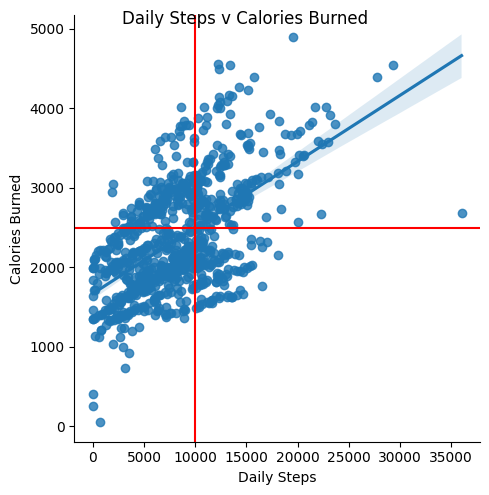

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
daily_step_calories = sns.lmplot(x='TotalSteps', y='Calories', data=daily_data)
daily_step_calories.fig.suptitle('Daily Steps v Calories Burned')
daily_step_calories.set_axis_labels('Daily Steps', 'Calories Burned')
_ = plt.axvline(x=10000, color='red')
_ = plt.axhline(y=2500, color='red')

There is a correlation between daily steps and calories. The more steps taken, the more calories one may burn. At 10,000 steps, a user will burn around ~2500 calories


Creating new column by separating the date into day of the week for further analysis.

In [23]:
# create new column "day_of_the_week" to represent day of the week
daily_data["DayOfTheWeek"] = daily_data["ActivityDate"].dt.day_name()

# print 1st 5 rows to confirm
daily_data["DayOfTheWeek"].head(5)

,DayOfTheWeek
0,Tuesday
1,Wednesday
2,Thursday
3,Friday
4,Saturday


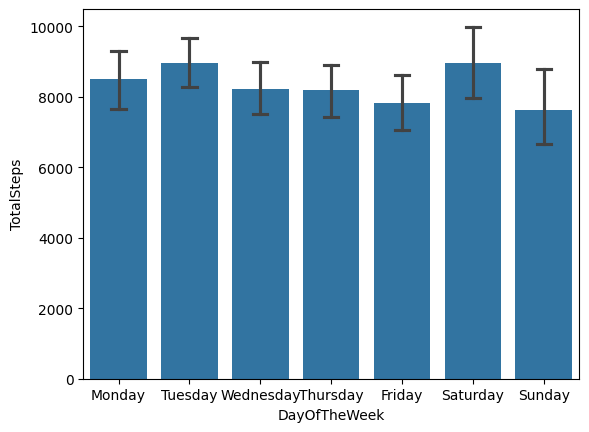

In [24]:
# Plot barchart DayOfWeek against TotalSteps
activity_by_week_day = sns.barplot(x="DayOfTheWeek", y="TotalSteps", data=daily_data,
                                   order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                                   capsize=.2)

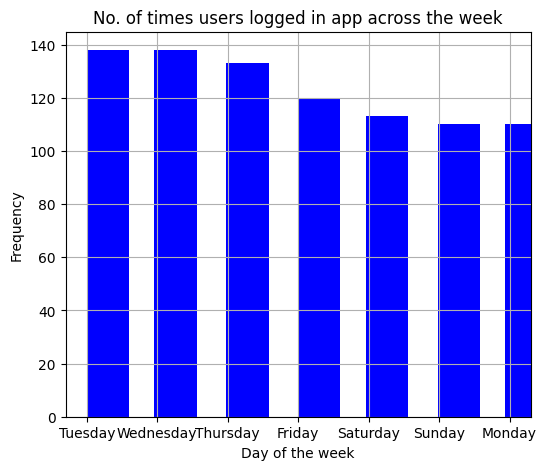

In [25]:
# plotting histogram
plt.style.use("default")
plt.figure(figsize=(6,5)) # specify size of the chart
plt.hist(daily_data.DayOfTheWeek, bins = 100,
         width = 0.6, color = "blue")

# adding annotations and visuals
plt.xlabel("Day of the week")
plt.ylabel("Frequency")
plt.title("No. of times users logged in app across the week")
plt.grid(True)
plt.show()

From the diagram, we can see that :
- Tuesday, Wednesday, and Thursday has higher frequency than others. It show that more people using smart device in the middle of the week.  

In [26]:
# Add HourOfDay and DayOfWeek column
hourly_data['HourOfDay'] = hourly_data['ActivityHour'].dt.hour
hourly_data['DayOfTheWeek'] = hourly_data['ActivityHour'].dt.day_name()

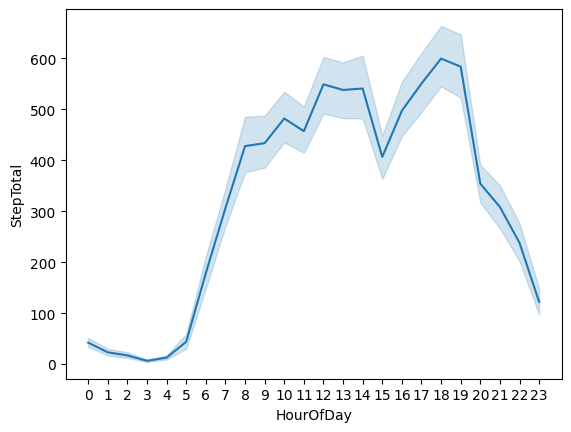

In [27]:
# Plot linechart on HourOfDay against StepTotal
hourly_activity_by_day_hour = sns.lineplot(x='HourOfDay', y='StepTotal', data=hourly_data)
_ = plt.xticks(hourly_data['HourOfDay'].unique())

From the diagram, we can see that :
- People are very active from 8 a.m all the way to 7 p.m.

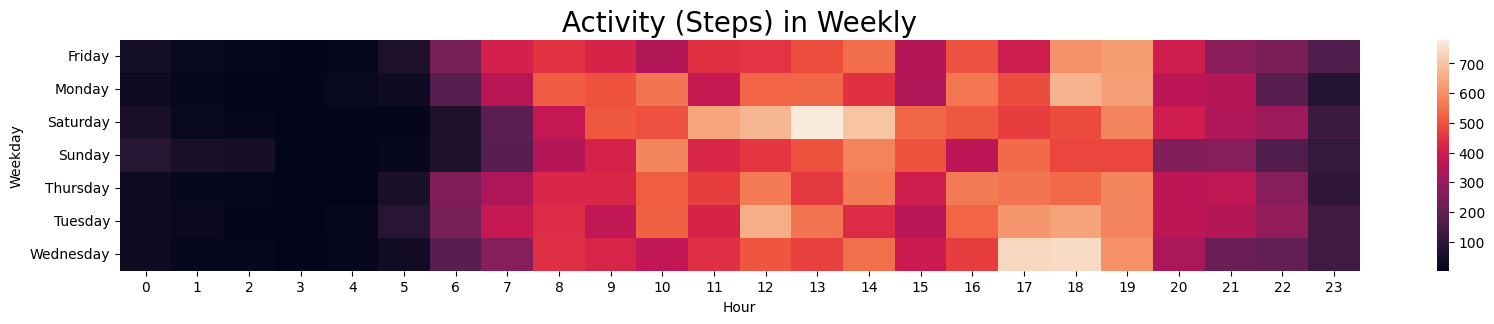

In [28]:
df = pd.DataFrame({'TotalSteps': hourly_data['StepTotal'],
                   'Hour': hourly_data['HourOfDay'],
                  'Weekday' : hourly_data['DayOfTheWeek']})

fig, ax = plt.subplots( figsize=(20,3))
out = df.groupby(['Weekday','Hour' ])['TotalSteps'].mean().unstack()
sns.heatmap(out)
ax.set_title("Activity (Steps) in Weekly", size=20)
plt.show()

Users are generally more active on Saturdays and in the afternoon.

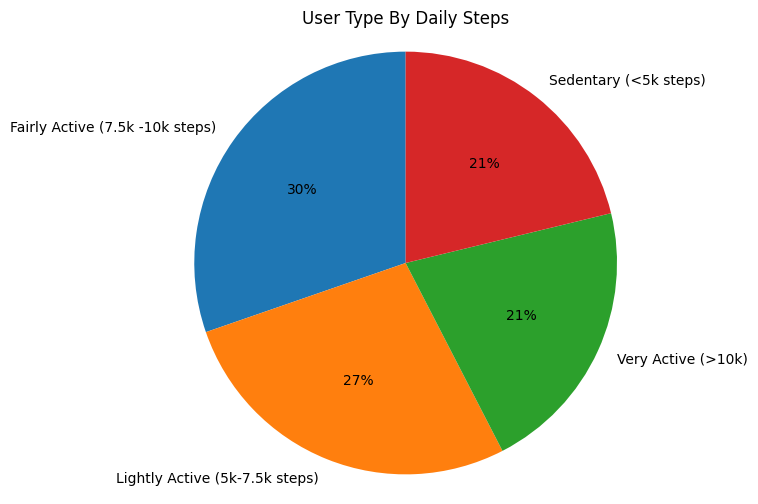

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asumsikan daily_data adalah DataFrame yang sudah tersedia

# Kelompokkan dan hitung rata-rata hanya untuk kolom numerik
user_data = daily_data.groupby(['Id']).mean(numeric_only=True)

# Tambahkan kolom UserType berdasarkan TotalSteps
user_data['UserType'] = np.where(user_data['TotalSteps'] < 5000, 'Sedentary (<5k steps)',
                         np.where(user_data['TotalSteps'] < 7500, 'Lightly Active (5k-7.5k steps)',
                         np.where(user_data['TotalSteps'] < 10000, 'Fairly Active (7.5k -10k steps)',
                                  'Very Active (>10k)')))

# Hitung jumlah user per kategori UserType
user_type_data = user_data['UserType'].value_counts()

# Buat pie chart
plt.figure(figsize=(6,6))
plt.pie(user_type_data, labels=user_type_data.index, autopct='%.0f%%', startangle=90)
plt.title('User Type By Daily Steps')
plt.axis('equal')  # Membuat pie chart bulat
plt.show()


# STEP 5: ACT

Key Insight and Recommendation

1. Users prefer to track their activities during weekdays as compared to weekends - perhaps because they spend more time outside on weekdays and stay in on weekends. From this insight, Bellabeat can actively give interesting article about health,fitness benefits, and calories intake and burnt rate information on the Bellabeat app so user can be inspired to be more active.
2. The data revealed that users has very low average steps per day and lower than recommended for healthy adults. Bellabeat can provide unique tips to help users achieve their daily objectives. Bellabeat also can make daily challenges and give some rewards such as discounts on coaching classes for the one that can influence others.
3. The data we explored shows that consumers are less active between 8 and 10 pm. This is the ideal moment for Bellabeat to schedule their advertising initiatives for optimal results.
4. For Bellabeat to retain its consumers, it must focus on personalized contents that offer value. For instance, the data revealed a positive correlation between the number of steps walked and the number of calories burnt. The more steps a person takes each day, the more calories they burn.

***

